# Training (Kalman Filter)

This notebook contains the code used to perform the main training loop for the Kalman filters. Note that we train two different versions, one with and one without the use of a pseudo-measurement to constrain the keypoints. The actual training code in implemented in `kflearn.py`.

In [7]:
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import kalman
import kflearn
import tracker
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(kalman)
importlib.reload(kflearn)
importlib.reload(tracker)
importlib.reload(dataset);

We now train the Kalman filter with the complete dataset. 

In [4]:
model = kalman.LearnedPhysics(tracker.build_constrained_physics())

# Train the model for some epochs in the complete dataset.
kflearn.train_epochs_in(50, "../nets/kalman", "../stats/kalman", model)

Loaded checkpoint for step 13.


/home/roland/dev/github/rolandbernard/capstone-project/venv/lib64/python3.14/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/home/roland/dev/github/rolandbernard/capstone-project/venv/lib64/python3.14/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/home/roland/dev/github/rolandbernard/capstone-project/venv/lib64/python3.14/site-packages/torch/_inductor/lowering.py:2158: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


epoch 14; train: loss 121.9717507502487; val: loss 116.64866432776817
epoch 15; train: loss 121.88650732813196; val: loss 116.69699709232037
epoch 16; train: loss 121.84267769301458; val: loss 116.4822347347553
epoch 17; train: loss 121.71685361649878; val: loss 116.42695474624634
epoch 18; train: loss 121.53046072113227; val: loss 116.28156577623807
epoch 19; train: loss 121.51798171521507; val: loss 116.42257437339195
epoch 20; train: loss 121.69937976215529; val: loss 116.71716062839215
epoch 21; train: loss 122.05600685534048; val: loss 117.25416025748619
epoch 22; train: loss 122.52814582152125; val: loss 117.52511526988103
epoch 23; train: loss 122.7851241087128; val: loss 117.81128410192636
epoch 24; train: loss 123.00248123807559; val: loss 118.04483652114868
epoch 25; train: loss 123.12241269771478; val: loss 117.76261751468365
epoch 26; train: loss 122.8723706035665; val: loss 117.67869710922241
epoch 27; train: loss 122.76113012488783; val: loss 117.2851205605727
epoch 28; t

In [5]:
util.NetStorage.training_stats("../stats/kalman") \
    .to_csv("../stats/kalman.csv", index=False)

#### Training and Validation Loss Curves

Below we will examine the training and validation loss curves for the training run.

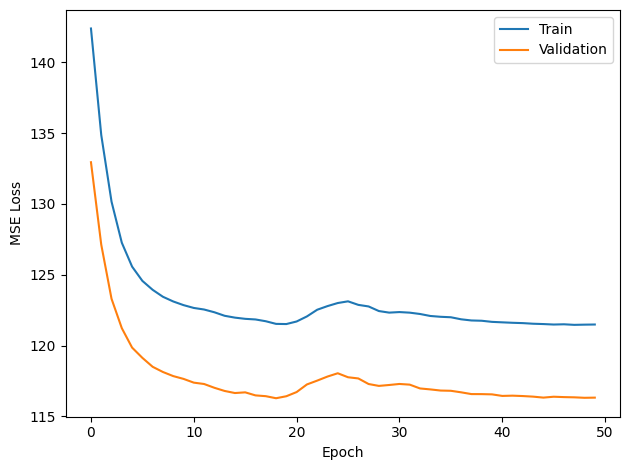

In [8]:
df = pd.read_csv("../stats/kalman.csv").sort_values("step")

plt.plot(df["step"], df["tr_loss"], label="Train")
plt.plot(df["step"], df["val_loss"], label="Validation")
plt.ylabel("MSE Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../presentation1/figures/lcurve-kalman.pdf",
            format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()